In [10]:
import sys
!{sys.executable} -m pip install plotly
!{sys.executable} -m pip install PyPortfolioOpt

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.8 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.8 MB/s  0:00:00
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/887.3 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/887.3 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 887.3/887.3 kB 1.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 2.2 MB/s eta 0:00:02
   -------------- ------------------------- 1.0/2.8 MB 1.7 MB/s eta 0:00:02
   -------------------------- ------------- 1.

In [57]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from pypfopt import EfficientFrontier, objective_functions
from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, plotting
from pypfopt import DiscreteAllocation

In [58]:
#create
holdings = ['NVDA', 'MSFT', 'TPL', 'EFX', 'TSLA'] 
    

In [59]:
#get data
portfolio = yf.download(holdings, start = '2016-01-01', end = '2026-08-17')['Close']
bench = yf.download('SPY', start = '2016-01-01', end = '2026-08-17')['Close']

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


In [60]:
#market caps
mcaps = {}
for t in holdings:
    stock = yf.Ticker(t)
    mcaps[t] = stock.info['marketCap']
mcaps

{'NVDA': 5449966944256,
 'MSFT': 3566861025280,
 'TPL': 24885374976,
 'EFX': 20771330048,
 'TSLA': 1340081438720}

In [61]:
#calc sigma and delta to get implied market returns
#ledoit-Wolf: a statistical method used to fix noisy or unstable covariance matrices by shrinking sample values toward a structured target.
s = risk_models.CovarianceShrinkage(portfolio).ledoit_wolf()

delta = black_litterman.market_implied_risk_aversion(bench)
delta

np.float64(5.046050320615138)

<Axes: xlabel='Ticker', ylabel='Ticker'>

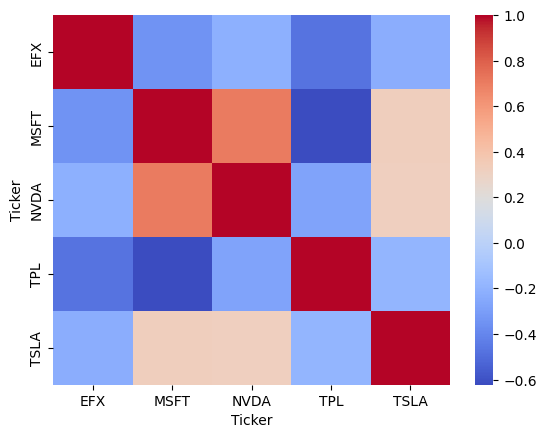

In [64]:
#heatmap
sns.heatmap(s.corr(), cmap='coolwarm')

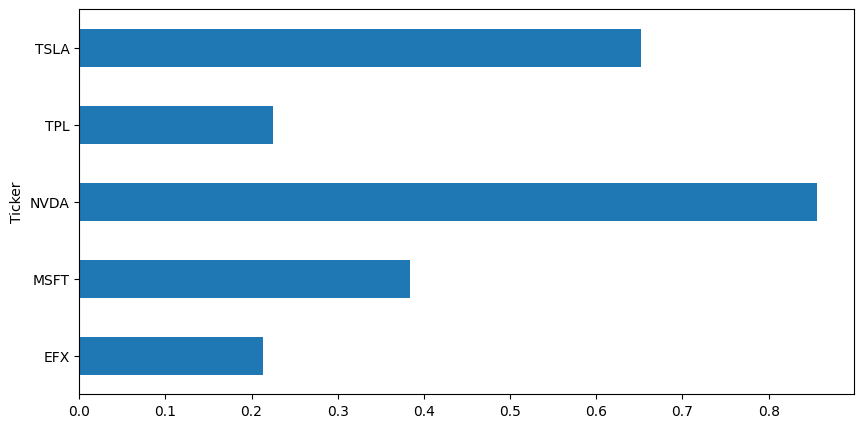

In [67]:
market_prior = black_litterman.market_implied_prior_returns(mcaps, delta, s)
market_prior.plot.barh(figsize=(10,5));
#how much are we gonna be compensated per risk; this alone does not integrate any assumptions from user

In [69]:
#do not need view on all
viewdict = {
    'TSLA':.17,
    'NVDA':.35,
    'MSFT':.3
}

bl = BlackLittermanModel(s, pi=market_prior, absolute_views=viewdict)

In [70]:
#look at is as a plausible range for standard deviation, again assumptions
intervals = [
    (-.12, .3),
    (.14, .64),
    (-.08, .4),
]

In [71]:
#up = upper band
variances = []
for lb, ub in intervals:
    sigma = (ub - lb)/2
    variances.append(sigma ** 2)

print(variances)
omega = np.diag(variances)


[0.04409999999999999, 0.0625, 0.05760000000000001]


In [72]:
#shortcuts to find market implied prior
bl = BlackLittermanModel(s, pi='market', market_caps=mcaps, risk_aversion=delta, absolute_views=viewdict, omega=omega)

In [74]:
#posterior returns estimate
ret_bl = bl.bl_returns()

In [76]:
rets_df = pd.DataFrame([market_prior, ret_bl, pd.Series(viewdict)], index=['Prior', 'Posterior', 'Views']).T
rets_df

,Prior,Posterior,Views
EFX,0.213685,0.182533,NaN
MSFT,0.384346,0.334719,0.30
NVDA,0.856351,0.735641,0.35
TPL,0.224345,0.187475,NaN
TSLA,0.651624,0.488997,0.17


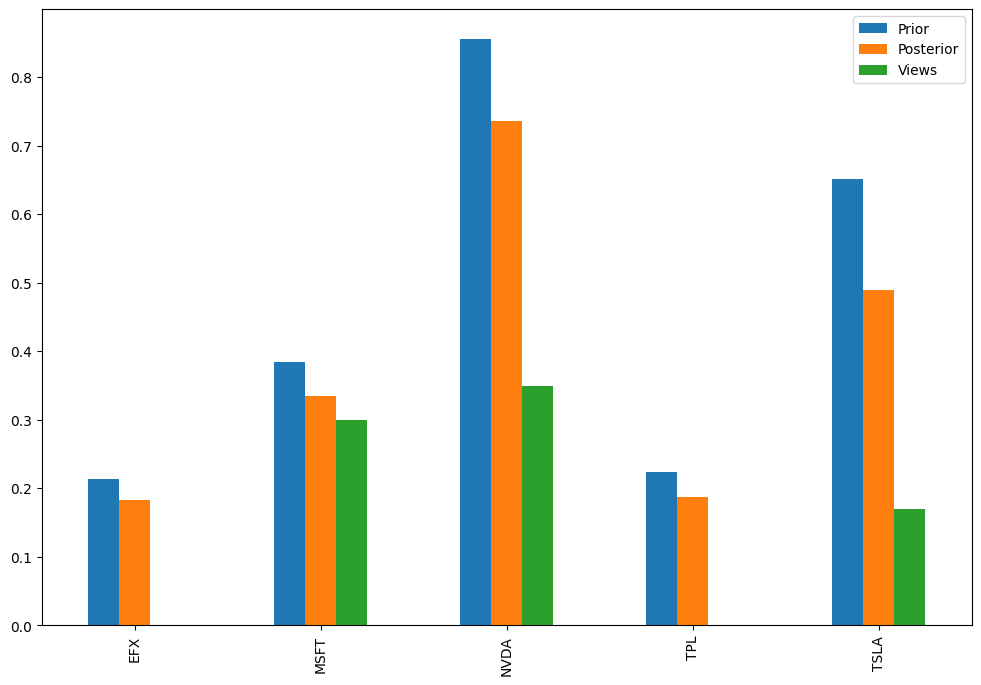

In [78]:
rets_df.plot.bar(figsize=(12,8));

In [81]:
ef = EfficientFrontier(ret_bl, s)
ef.add_objective(objective_functions.L2_reg)
ef.max_sharpe()
weights = ef.clean_weights()
weights

C:\Users\torle\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pypfopt\efficient_frontier\efficient_frontier.py:259: UserWarning: max_sharpe transforms the optimization problem so additional objectives may not work as expected.
  warnings.warn(


OrderedDict([('EFX', 0.09196),
             ('MSFT', 0.18842),
             ('NVDA', 0.41075),
             ('TPL', 0.08313),
             ('TSLA', 0.22574)])

Expected annual return: 50.8%
Annual volatility: 34.2%
Sharpe Ratio: 1.49


C:\Users\torle\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pypfopt\efficient_frontier\efficient_frontier.py:441: UserWarning: The risk_free_rate provided to portfolio_performance is different to the one used by max_sharpe. Using the previous value.
  warnings.warn(


(np.float64(0.5079901412664435),
 np.float64(0.3417927521403482),
 np.float64(1.4862519409359818))

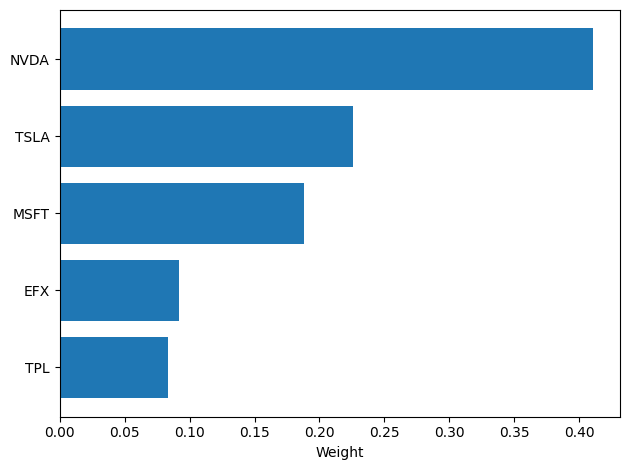

In [82]:
from pypfopt.plotting import plot_weights

#max sharpe
ef = EfficientFrontier(ret_bl, s)
ef.add_objective(objective_functions.L2_reg)
ef.max_sharpe()
weights = ef.clean_weights()
weights

plot_weights(weights)
ef.portfolio_performance(verbose = True, risk_free_rate = .06)